Categories found: ['MONOCYTE', 'NEUTROPHIL', 'LYMPHOCYTE', 'EOSINOPHIL']
Category : MONOCYTE
Images   : 2478

Loaded : _7_6446.jpeg
Shape  : (128, 128, 3)

✅ K-Means done.

Running FCM (pure numpy)...
  FCM converged at iteration 12
✅ FCM done.
   Fuzzy Partition Coefficient (FPC) : 0.2785  (1.0 = perfect)

📊 Jaccard Similarity — K-Means vs FCM (per cluster):
   Cluster 0 : 0.0000
   Cluster 1 : 0.0000
   Cluster 2 : 0.0022

📊 Boundary Pixel Count:
   K-Means : 1745
   FCM     : 1745


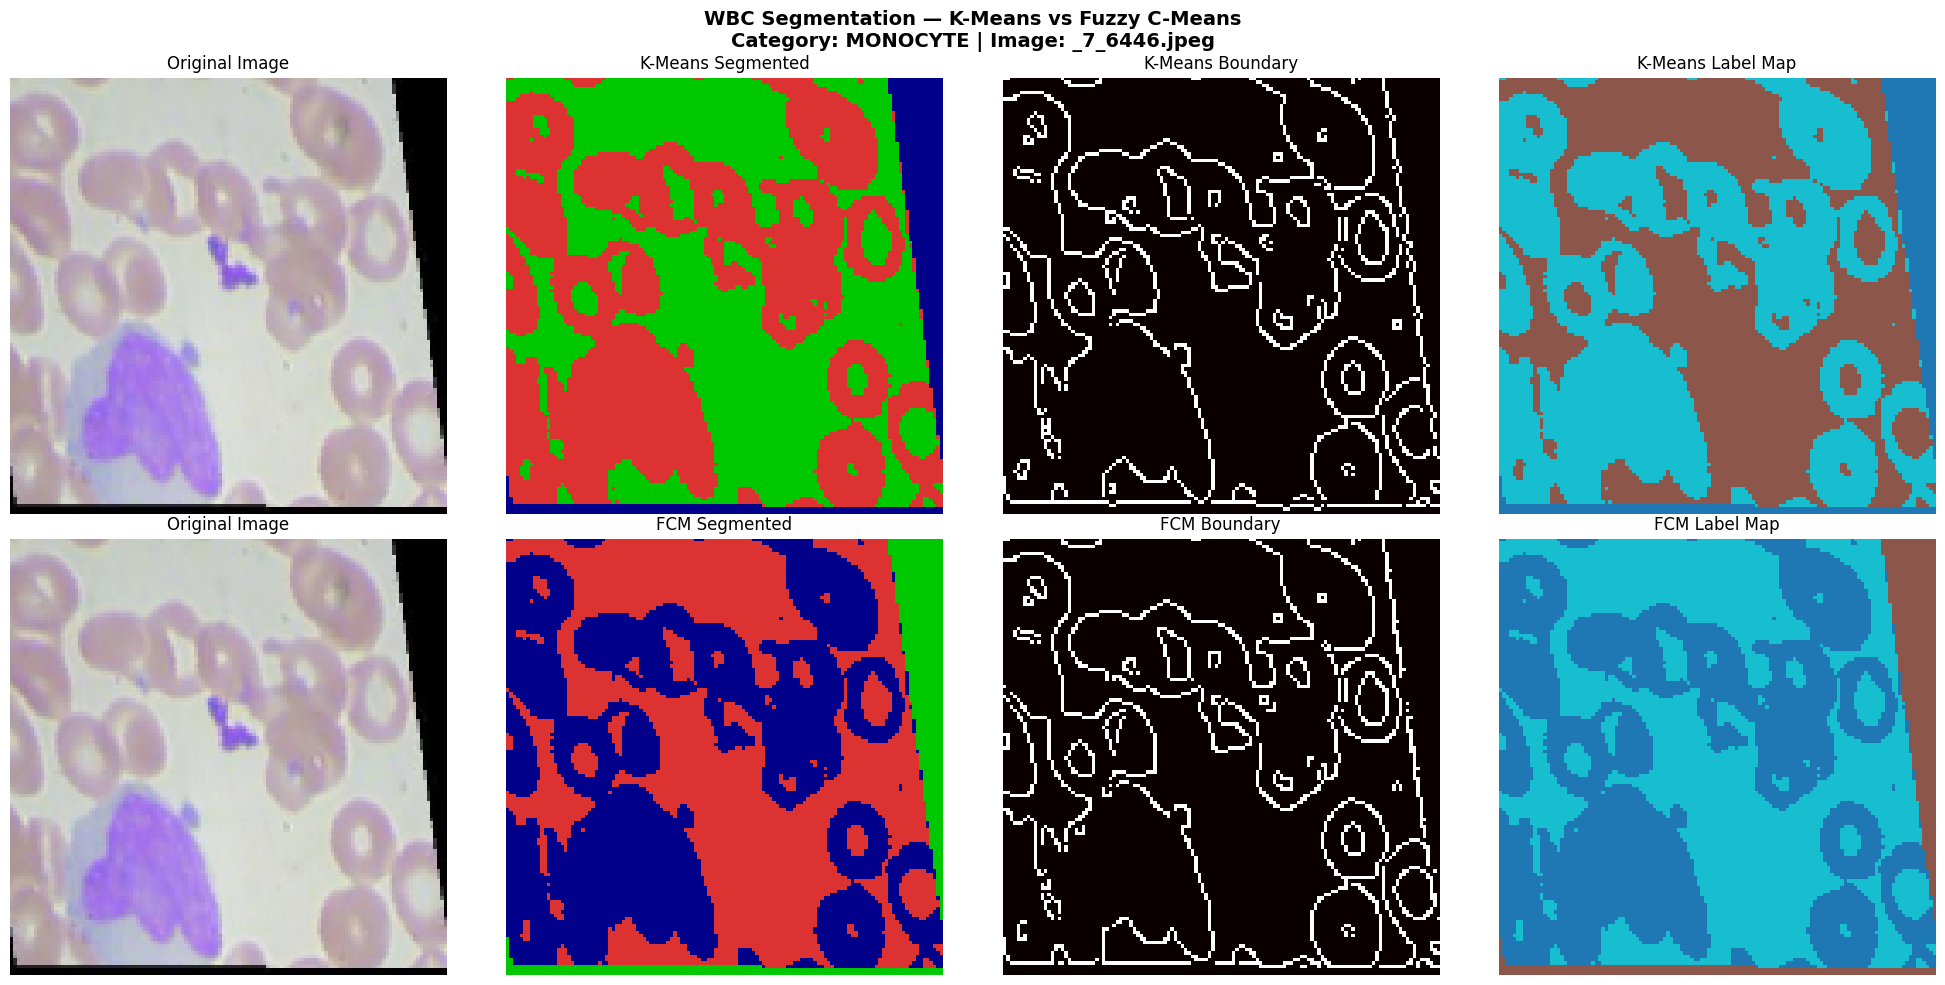


✅ Plot saved: wbc_segmentation_comparison.png

--- Batch Analysis (5 images) ---
Image                                    FPC     J-C0     J-C1     J-C2   KM-Boundary  FCM-Boundary
----------------------------------------------------------------------------------------------------
  FCM converged at iteration 12
_7_6446.jpeg                          0.2785   0.0000   0.0000   0.0022          1745          1745
  FCM converged at iteration 11
_9_2647.jpeg                          0.2829   0.9919   0.0000   0.0000          1677          1648
  FCM converged at iteration 11
_8_2259.jpeg                          0.2931   0.0003   0.0000   0.0000          1538          1537
  FCM converged at iteration 12
_1_8927.jpeg                          0.2865   0.0000   0.0001   0.9939          1675          1664
  FCM converged at iteration 9
_3_4538.jpeg                          0.2895   0.0000   0.0000   0.9929          1573          1562
  FCM converged at iteration 12
  FCM converged at iterati

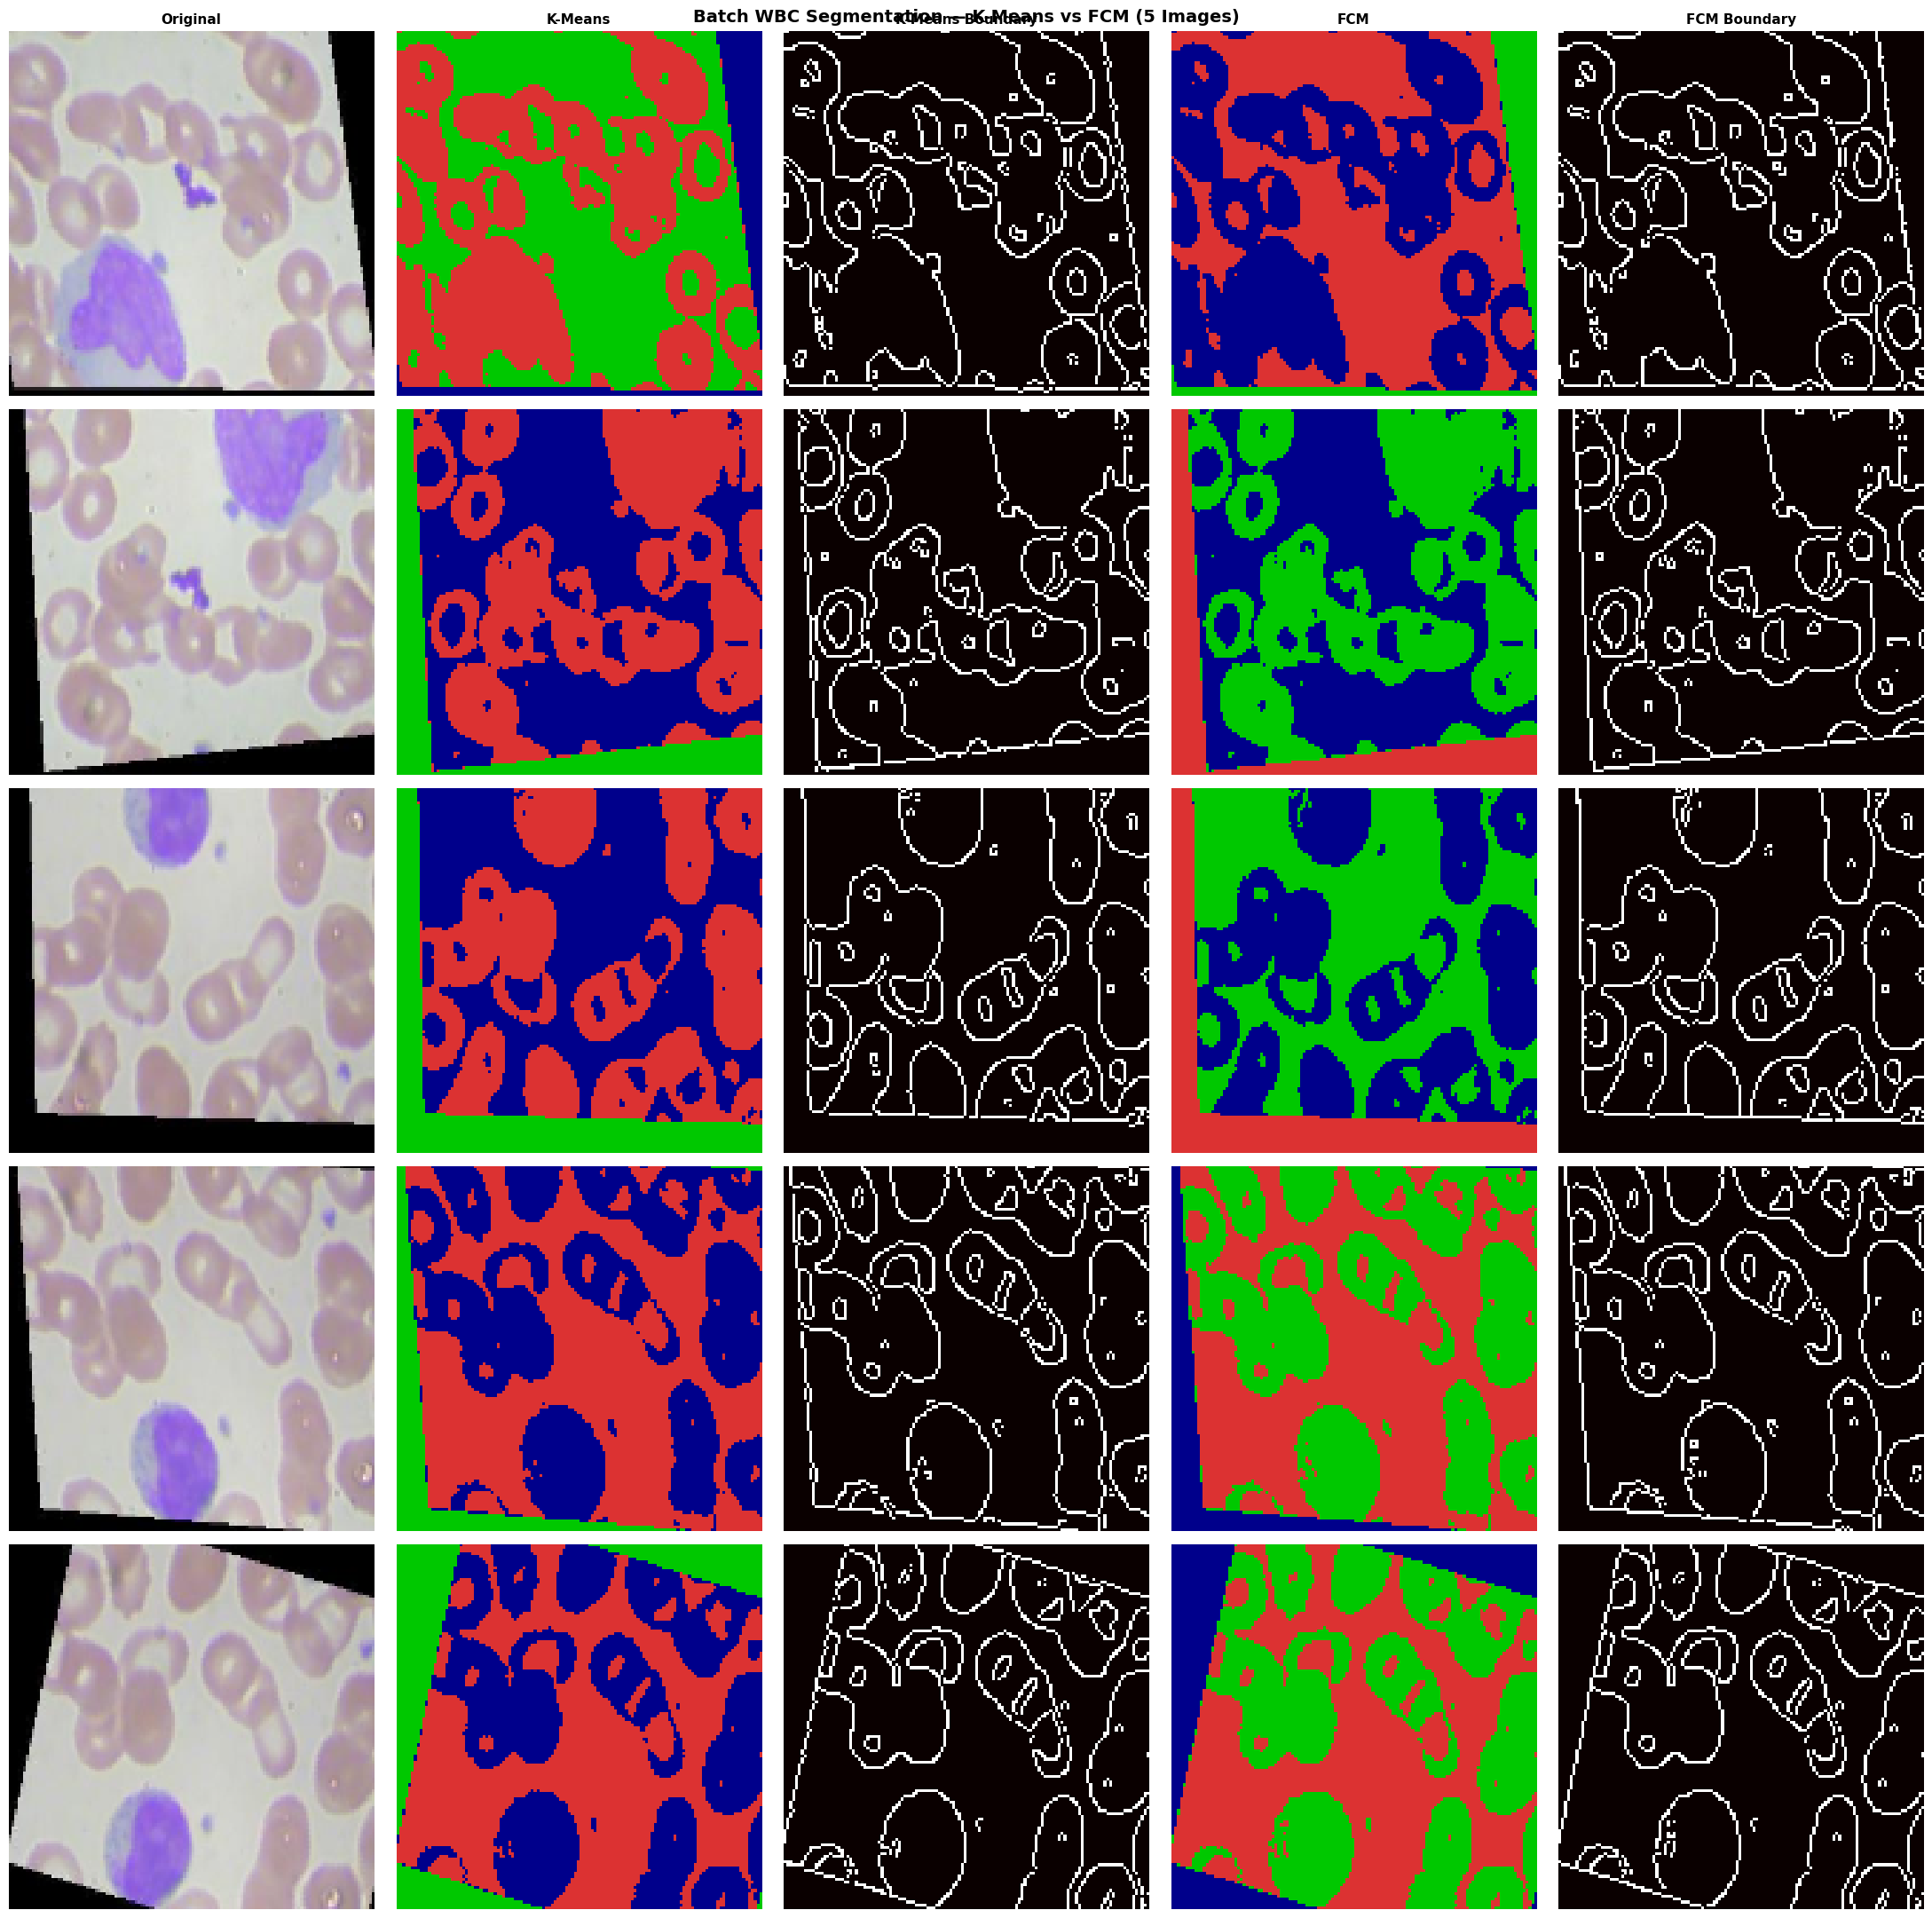

✅ Batch plot saved: wbc_batch_comparison.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.cluster import KMeans
from glob import glob

def fuzzy_cmeans(X, c=3, m=2, max_iter=100, error=0.005, seed=42):
    np.random.seed(seed)
    N = X.shape[0]
    U = np.random.dirichlet(np.ones(c), size=N)

    for iteration in range(max_iter):
        U_old = U.copy()
        Um = U ** m
        centers = (Um.T @ X) / Um.sum(axis=0)[:, np.newaxis]
        dist = np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)
        dist = np.fmax(dist, 1e-10)
        exp = 2 / (m - 1)
        U = 1 / np.sum((dist[:, :, np.newaxis] / dist[:, np.newaxis, :]) ** exp, axis=2)
        if np.max(np.abs(U - U_old)) < error:
            print(f"  FCM converged at iteration {iteration+1}")
            break

    labels = np.argmax(U, axis=1)
    fpc = np.mean(U ** 2)
    return labels, centers, fpc

def jaccard(map1, map2, cluster_id):
    m1    = (map1 == cluster_id).flatten().astype(int)
    m2    = (map2 == cluster_id).flatten().astype(int)
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return inter / union if union > 0 else 0

def get_boundary(seg_map):
    return cv2.Canny((seg_map.astype(np.uint8)) * 80, 50, 150)

TRAIN_PATH = '/kaggle/input/blood-cells/dataset2-master/dataset2-master/images/TRAIN'
categories = os.listdir(TRAIN_PATH)
print("Categories found:", categories)

category     = categories[0]
image_folder = os.path.join(TRAIN_PATH, category)
image_files  = glob(os.path.join(image_folder, '*.jpg'))  + \
               glob(os.path.join(image_folder, '*.jpeg')) + \
               glob(os.path.join(image_folder, '*.png'))

print(f"Category : {category}")
print(f"Images   : {len(image_files)}")

img_path    = image_files[0]
img_bgr     = cv2.imread(img_path)
img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (128, 128))
pixel_data  = img_resized.reshape(-1, 3).astype(np.float32)

print(f"\nLoaded : {os.path.basename(img_path)}")
print(f"Shape  : {img_resized.shape}")

K = 3
kmeans    = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(pixel_data)
km_map    = km_labels.reshape(128, 128)
print("\n✅ K-Means done.")

print("\nRunning FCM (pure numpy)...")
fcm_labels, fcm_centers, fpc = fuzzy_cmeans(pixel_data, c=K, m=2, max_iter=100)
fcm_map = fcm_labels.reshape(128, 128)
print(f"✅ FCM done.")
print(f"   Fuzzy Partition Coefficient (FPC) : {fpc:.4f}  (1.0 = perfect)")

colors = [(0, 0, 139), (0, 200, 0), (220, 50, 50)]

km_colored  = np.zeros((128, 128, 3), dtype=np.uint8)
fcm_colored = np.zeros((128, 128, 3), dtype=np.uint8)

for i in range(K):
    km_colored[km_map == i]   = colors[i]
    fcm_colored[fcm_map == i] = colors[i]

km_boundary  = get_boundary(km_map)
fcm_boundary = get_boundary(fcm_map)

print("\n📊 Jaccard Similarity — K-Means vs FCM (per cluster):")
for c in range(K):
    print(f"   Cluster {c} : {jaccard(km_map, fcm_map, c):.4f}")

print(f"\n📊 Boundary Pixel Count:")
print(f"   K-Means : {np.sum(km_boundary > 0)}")
print(f"   FCM     : {np.sum(fcm_boundary > 0)}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    f'WBC Segmentation — K-Means vs Fuzzy C-Means\nCategory: {category} | Image: {os.path.basename(img_path)}',
    fontsize=14, fontweight='bold'
)

axes[0, 0].imshow(img_resized);              axes[0, 0].set_title('Original Image', fontsize=12)
axes[0, 1].imshow(km_colored);               axes[0, 1].set_title('K-Means Segmented', fontsize=12)
axes[0, 2].imshow(km_boundary, cmap='hot');  axes[0, 2].set_title('K-Means Boundary', fontsize=12)
axes[0, 3].imshow(km_map, cmap='tab10');     axes[0, 3].set_title('K-Means Label Map', fontsize=12)

axes[1, 0].imshow(img_resized);               axes[1, 0].set_title('Original Image', fontsize=12)
axes[1, 1].imshow(fcm_colored);               axes[1, 1].set_title('FCM Segmented', fontsize=12)
axes[1, 2].imshow(fcm_boundary, cmap='hot');  axes[1, 2].set_title('FCM Boundary', fontsize=12)
axes[1, 3].imshow(fcm_map, cmap='tab10');     axes[1, 3].set_title('FCM Label Map', fontsize=12)

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.savefig('wbc_segmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved: wbc_segmentation_comparison.png")

print("\n--- Batch Analysis (5 images) ---")
print(f"{'Image':<35} {'FPC':>8} {'J-C0':>8} {'J-C1':>8} {'J-C2':>8} {'KM-Boundary':>13} {'FCM-Boundary':>13}")
print("-" * 100)

for path in image_files[:5]:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    pix = img.reshape(-1, 3).astype(np.float32)

    km   = KMeans(n_clusters=3, random_state=42, n_init=10)
    km_l = km.fit_predict(pix).reshape(128, 128)

    fcm_l_flat, _, fpc_b = fuzzy_cmeans(pix, c=3, m=2, max_iter=100)
    fcm_l = fcm_l_flat.reshape(128, 128)

    j    = [jaccard(km_l, fcm_l, c) for c in range(3)]
    km_b = np.sum(get_boundary(km_l) > 0)
    fcm_b= np.sum(get_boundary(fcm_l) > 0)

    print(f"{os.path.basename(path):<35} {fpc_b:>8.4f} {j[0]:>8.4f} {j[1]:>8.4f} {j[2]:>8.4f} {km_b:>13} {fcm_b:>13}")

fig2, axes2 = plt.subplots(5, 5, figsize=(22, 22))
fig2.suptitle('Batch WBC Segmentation — K-Means vs FCM (5 Images)', fontsize=14, fontweight='bold')

col_titles = ['Original', 'K-Means', 'K-Means Boundary', 'FCM', 'FCM Boundary']
for col, title in enumerate(col_titles):
    axes2[0, col].set_title(title, fontsize=11, fontweight='bold')

for row, path in enumerate(image_files[:5]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    pix = img.reshape(-1, 3).astype(np.float32)

    km   = KMeans(n_clusters=3, random_state=42, n_init=10)
    km_l = km.fit_predict(pix).reshape(128, 128)

    fcm_l_flat, _, _ = fuzzy_cmeans(pix, c=3, m=2, max_iter=100)
    fcm_l = fcm_l_flat.reshape(128, 128)

    km_c  = np.zeros((128, 128, 3), dtype=np.uint8)
    fcm_c = np.zeros((128, 128, 3), dtype=np.uint8)
    for i in range(3):
        km_c[km_l == i]   = colors[i]
        fcm_c[fcm_l == i] = colors[i]

    km_b_img  = get_boundary(km_l)
    fcm_b_img = get_boundary(fcm_l)

    axes2[row, 0].imshow(img)
    axes2[row, 1].imshow(km_c)
    axes2[row, 2].imshow(km_b_img, cmap='hot')
    axes2[row, 3].imshow(fcm_c)
    axes2[row, 4].imshow(fcm_b_img, cmap='hot')
    axes2[row, 0].set_ylabel(os.path.basename(path)[:15], fontsize=8)

for ax in axes2.flatten():
    ax.axis('off')

plt.tight_layout()
plt.savefig('wbc_batch_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Batch plot saved: wbc_batch_comparison.png")